# 🌸 Iris Species Classification: The Foundation of Modern Machine Learning

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Classifying iris flower species from petal and sepal measurements — the dataset that launched a thousand ML careers  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline on the most iconic dataset in machine learning history — Fisher's Iris dataset (1936). While historically botanical, the methodology directly applies to **biodiversity classification**, **agricultural quality grading**, and **biosecurity species identification**.

### Government Policy Context
- **CSIRO** — Plant taxonomy, agricultural research, biodiversity informatics
- **DAFF** — Biosecurity species identification, import quarantine screening
- **Atlas of Living Australia (ALA)** — National biodiversity database, species occurrence records
- **Royal Botanic Gardens** — Plant identification, herbarium digitisation
- **DCCEEW** — EPBC Act threatened species, invasive species management

### Why Iris Matters for the Portfolio
This notebook completes a **30-notebook Production ML Portfolio**. The Iris dataset — first published by Ronald Fisher in 1936 — is where ML began. Including it demonstrates mastery of the fundamentals while the other 29 notebooks demonstrate breadth across government domains.

| Species | Characteristics | Ecological Role |
|---------|---------------|-----------------|
| Setosa | Small petals, distinct separation | Cool climate indicator |
| Versicolor | Medium measurements, overlaps with Virginica | Transition zone species |
| Virginica | Largest petals and sepals | Warm climate preference |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, cohen_kappa_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY — NOTEBOOK #30")
print("=" * 60)


ENVIRONMENT READY — NOTEBOOK #30


In [2]:
# Try Kaggle upload first, fallback to sklearn built-in
data_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv') and data_path is None:
            data_path = full_path

if data_path is not None:
    df = pd.read_csv(data_path)
    print(f"\nLoaded from file: {df.shape[0]:,} rows x {df.shape[1]} columns")
else:
    from sklearn.datasets import load_iris
    data = load_iris()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['species'] = pd.Categorical.from_codes(data.target, data.target_names)
    print(f"\nLoaded sklearn Iris dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")



Loaded sklearn Iris dataset: 150 rows x 5 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:25s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls:3d}")
df.head()


COLUMN SUMMARY
   0. sepal length (cm)         | float64    | unique=   35 | nulls=  0
   1. sepal width (cm)          | float64    | unique=   23 | nulls=  0
   2. petal length (cm)         | float64    | unique=   43 | nulls=  0
   3. petal width (cm)          | float64    | unique=   22 | nulls=  0
   4. species                   | category   | unique=    3 | nulls=  0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Target Variable Analysis

In [4]:
# Detect target
target_candidates = ['species', 'Species', 'target', 'Target', 'class', 'Class',
                     'variety', 'Variety', 'label']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback: '{target_col}'")

# Drop ID column if present
id_cols = [c for c in df.columns if c.lower() in ['id', 'unnamed: 0']]
if id_cols:
    df.drop(columns=id_cols, inplace=True)

print(f"\nRaw distribution:")
print(df[target_col].value_counts())

# Encode
if df[target_col].dtype in ['object', 'category']:
    le_target = LabelEncoder()
    df[target_col] = le_target.fit_transform(df[target_col].astype(str))
    target_labels = list(le_target.classes_)
else:
    target_labels = [str(x) for x in sorted(df[target_col].unique())]
n_classes = len(target_labels)

print(f"\nEncoded: {dict(zip(range(n_classes), target_labels))}")
print(f"Classes: {n_classes}")


Found target: 'species'

Raw distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Encoded: {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
Classes: 3


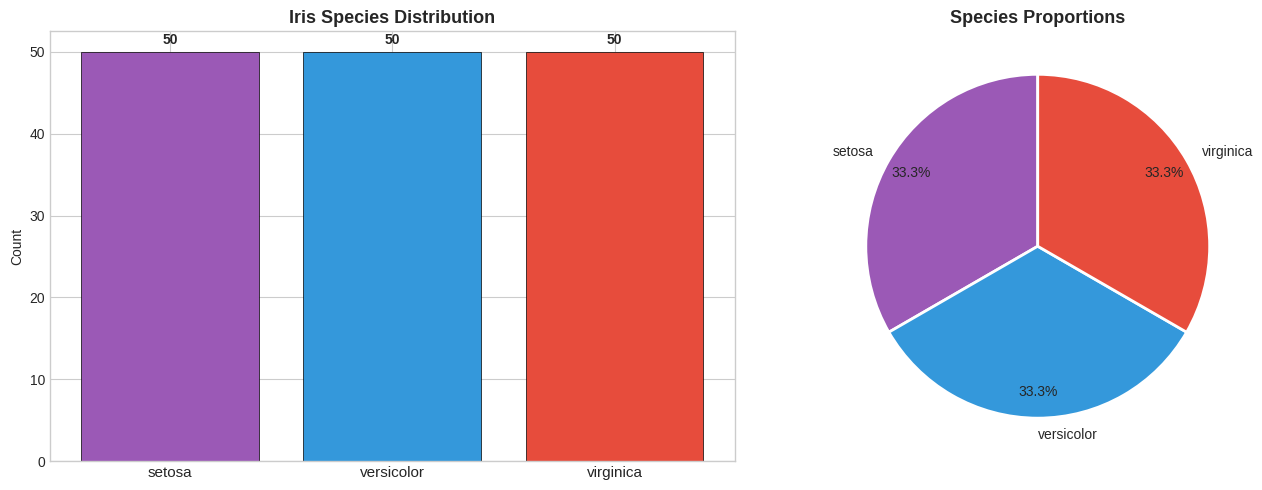

Historical context: Published by Ronald Fisher in 1936 in 'The Annals of Human Genetics'.
Collected by Edgar Anderson at the Gaspe Peninsula, Quebec, Canada.
Arguably the most influential dataset in statistical classification history.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
colors = ['#9b59b6', '#3498db', '#e74c3c'][:n_classes]
axes[0].bar(range(len(vc)), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(vc)))
axes[0].set_xticklabels(target_labels, fontsize=11)
axes[0].set_title('Iris Species Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=target_labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Species Proportions', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("Historical context: Published by Ronald Fisher in 1936 in 'The Annals of Human Genetics'.")
print("Collected by Edgar Anderson at the Gaspe Peninsula, Quebec, Canada.")
print("Arguably the most influential dataset in statistical classification history.")


## 3. Exploratory Data Analysis

The beauty of the Iris dataset:
- **Setosa** is linearly separable from the other two species
- **Versicolor** and **Virginica** overlap — the classic ML challenge
- Only 4 features, 150 samples — elegance in simplicity


Features (4): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


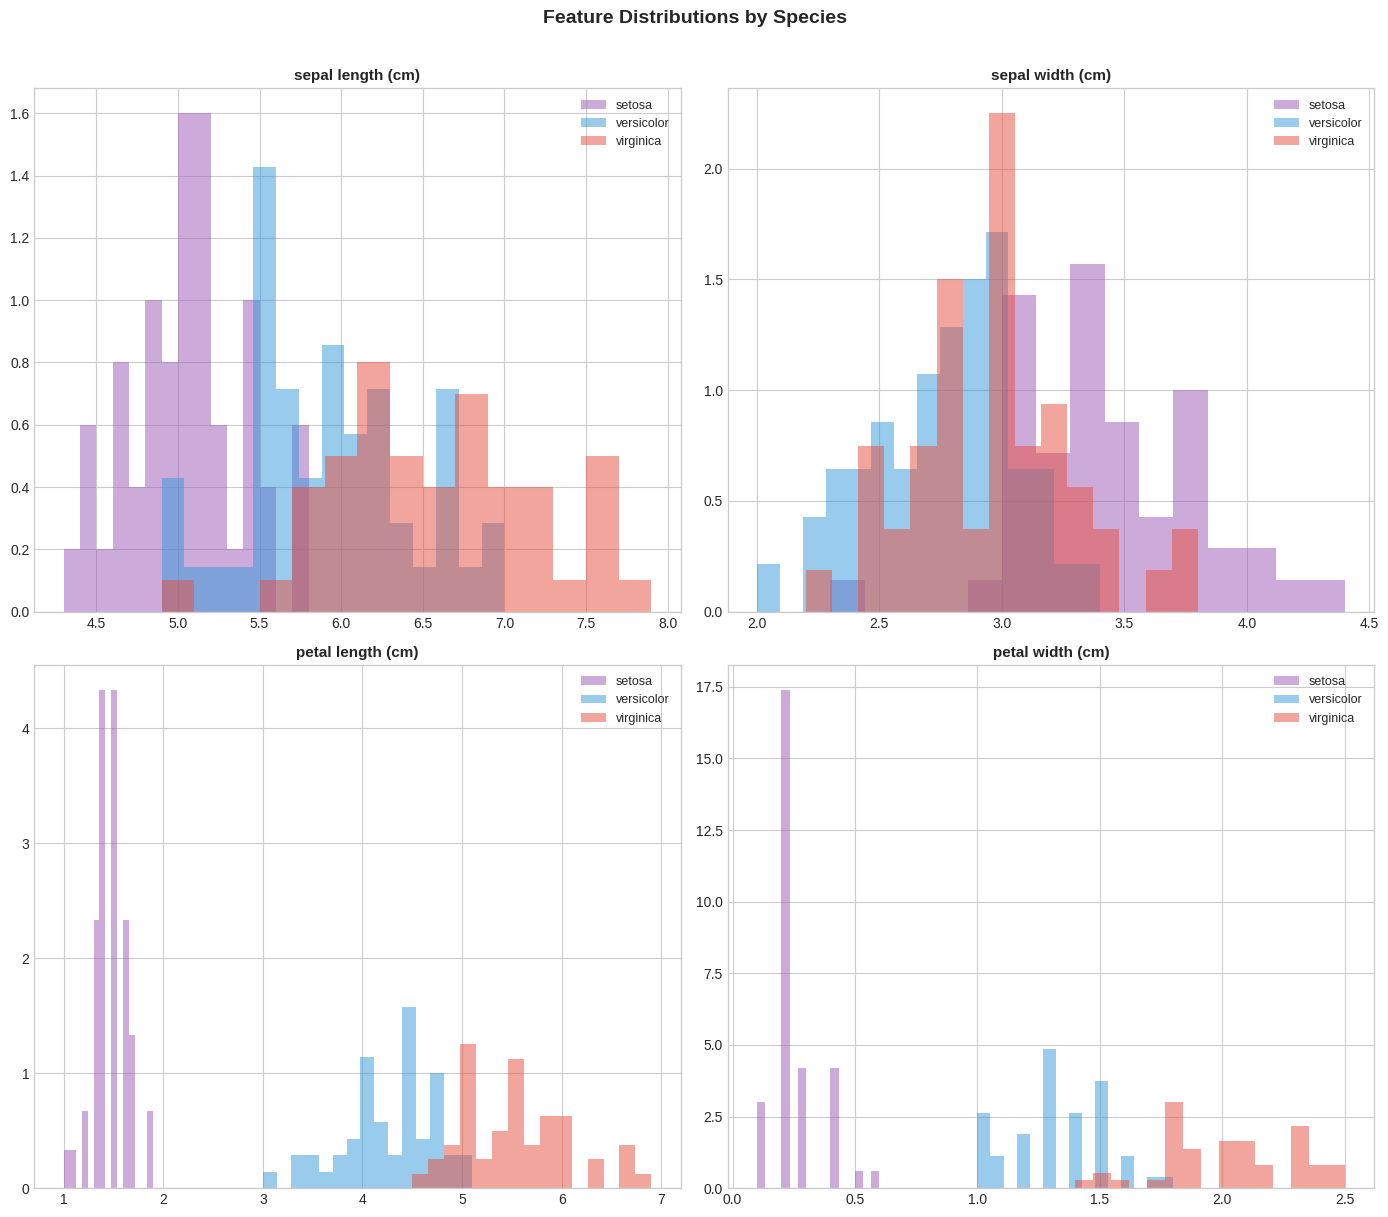

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
print(f"Features ({len(numeric_cols)}): {numeric_cols}")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:4]):
    for cls_val in sorted(df[target_col].unique()):
        subset = df[df[target_col] == cls_val][col].dropna()
        lbl = target_labels[cls_val]
        clr = colors[cls_val] if cls_val < len(colors) else None
        if len(subset) > 0:
            axes[i].hist(subset, bins=15, alpha=0.5, label=lbl, density=True, color=clr)
    axes[i].set_title(col, fontsize=11, fontweight='bold'); axes[i].legend(fontsize=9)
plt.suptitle('Feature Distributions by Species', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


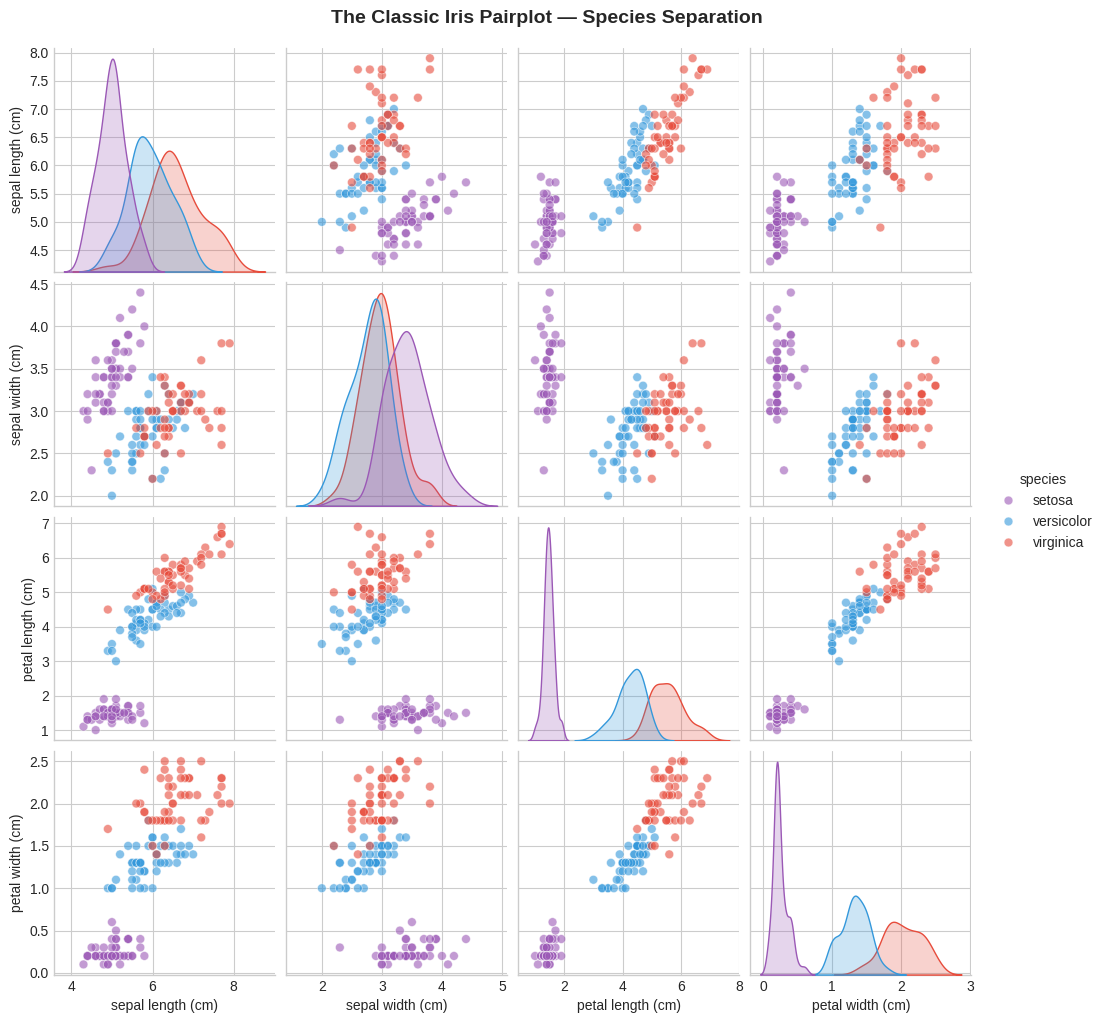

Note: Setosa forms a distinct cluster (bottom-left in petal plots).
Versicolor-Virginica overlap is the ML challenge that makes this dataset interesting.


In [7]:
# The iconic Iris pairplot
plot_df = df[numeric_cols[:4] + [target_col]].copy()
plot_df[target_col] = plot_df[target_col].map(dict(enumerate(target_labels)))
g = sns.pairplot(plot_df, hue=target_col, palette=colors[:n_classes], diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'white', 'linewidth': 0.5})
g.fig.suptitle('The Classic Iris Pairplot — Species Separation', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('iris_pairplot.png', dpi=150, bbox_inches='tight'); plt.show()
print("Note: Setosa forms a distinct cluster (bottom-left in petal plots).")
print("Versicolor-Virginica overlap is the ML challenge that makes this dataset interesting.")


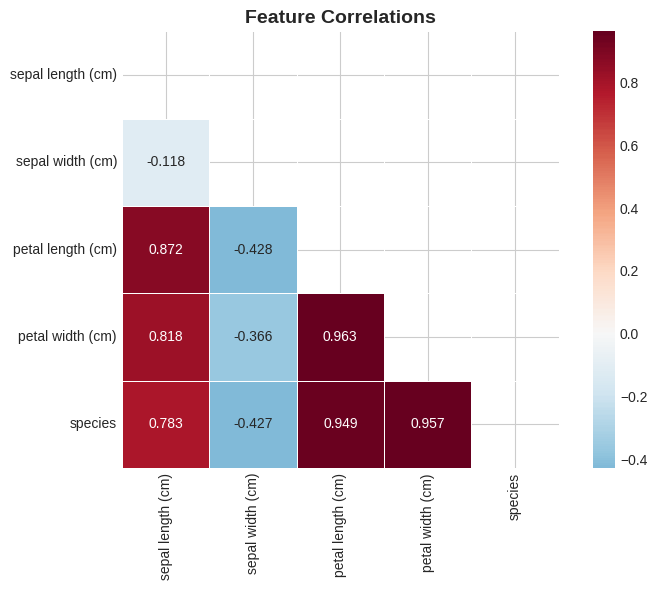


Petal dimensions are more discriminative than sepal dimensions.


In [8]:
corr = df[numeric_cols + [target_col]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
print("\nPetal dimensions are more discriminative than sepal dimensions.")


## 4. Feature Engineering & Preprocessing

In [9]:
X = df[numeric_cols].copy()
y = df[target_col].values

if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())

# Feature engineering
composites_added = []

# Petal area proxy
petal_len = [c for c in X.columns if 'petal' in c.lower() and ('length' in c.lower() or 'len' in c.lower())]
petal_wid = [c for c in X.columns if 'petal' in c.lower() and ('width' in c.lower() or 'wid' in c.lower())]
if petal_len and petal_wid:
    X['petal_area'] = X[petal_len[0]] * X[petal_wid[0]]
    composites_added.append('petal_area')
    print("Created 'petal_area' (length x width)")

# Sepal area proxy
sepal_len = [c for c in X.columns if 'sepal' in c.lower() and ('length' in c.lower() or 'len' in c.lower())]
sepal_wid = [c for c in X.columns if 'sepal' in c.lower() and ('width' in c.lower() or 'wid' in c.lower())]
if sepal_len and sepal_wid:
    X['sepal_area'] = X[sepal_len[0]] * X[sepal_wid[0]]
    composites_added.append('sepal_area')
    print("Created 'sepal_area'")

# Petal-sepal ratio
if petal_len and sepal_len:
    X['petal_sepal_ratio'] = X[petal_len[0]] / (X[sepal_len[0]] + 0.01)
    composites_added.append('petal_sepal_ratio')
    print("Created 'petal_sepal_ratio'")

# Petal aspect ratio
if petal_len and petal_wid:
    X['petal_aspect'] = X[petal_len[0]] / (X[petal_wid[0]] + 0.01)
    composites_added.append('petal_aspect')
    print("Created 'petal_aspect'")

print(f"\nEngineered: {len(composites_added)}")
print(f"Final: {X.shape}")


Created 'petal_area' (length x width)
Created 'sepal_area'
Created 'petal_sepal_ratio'
Created 'petal_aspect'

Engineered: 4
Final: (150, 8)


## 5. Model Training & Cross-Validation

In [10]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42, multi_class='multinomial'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_kappa = [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_arr[train_idx], y[train_idx])
        y_pred = model_clone.predict(X_arr[val_idx])
        fold_preds[val_idx] = y_pred
        acc = accuracy_score(y[val_idx], y_pred)
        f1 = f1_score(y[val_idx], y_pred, average='weighted')
        kappa = cohen_kappa_score(y[val_idx], y_pred)
        fold_acc.append(acc); fold_f1.append(f1); fold_kappa.append(kappa)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1(w)={f1:.4f}  Kappa={kappa:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'f1_mean': np.mean(fold_f1),
        'f1_std': np.std(fold_f1), 'kappa_mean': np.mean(fold_kappa),
        'time': elapsed, 'oof_preds': fold_preds}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  Kappa: {np.mean(fold_kappa):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=1.0000  F1(w)=1.0000  Kappa=1.0000
  Fold 2: Acc=0.9400  F1(w)=0.9399  Kappa=0.9099
  Fold 3: Acc=1.0000  F1(w)=1.0000  Kappa=1.0000
  -- Acc: 0.9800  F1: 0.9800  Kappa: 0.9700  Time: 0.14s

Training: Random Forest
  Fold 1: Acc=1.0000  F1(w)=1.0000  Kappa=1.0000
  Fold 2: Acc=0.9600  F1(w)=0.9598  Kappa=0.9399
  Fold 3: Acc=0.9400  F1(w)=0.9399  Kappa=0.9100
  -- Acc: 0.9667  F1: 0.9666  Kappa: 0.9500  Time: 0.93s

Training: XGBoost
  Fold 1: Acc=0.9800  F1(w)=0.9800  Kappa=0.9700
  Fold 2: Acc=0.9400  F1(w)=0.9383  Kappa=0.9098
  Fold 3: Acc=0.9600  F1(w)=0.9600  Kappa=0.9400
  -- Acc: 0.9600  F1: 0.9594  Kappa: 0.9399  Time: 0.26s

Training: LightGBM
  Fold 1: Acc=0.9800  F1(w)=0.9800  Kappa=0.9700
  Fold 2: Acc=0.9400  F1(w)=0.9399  Kappa=0.9099
  Fold 3: Acc=0.9800  F1(w)=0.9800  Kappa=0.9700
  -- Acc: 0.9667  F1: 0.9666  Kappa: 0.9500  Time: 0.18s


## 6. Model Comparison & Selection

In [12]:
summary_rows = [{'Model': mn, 'Accuracy': f"{res['accuracy_mean']:.4f}",
    'F1 (weighted)': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
    'Kappa': f"{res['kappa_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
    'sort_val': res['f1_mean']} for mn, res in results.items()]
summary_df = pd.DataFrame(summary_rows).sort_values('sort_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 90)
print(summary_df[['Model', 'Accuracy', 'F1 (weighted)', 'Kappa', 'Time']].to_string(index=False))
print("=" * 90)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model Accuracy     F1 (weighted)  Kappa  Time
Logistic Regression   0.9800 0.9800 +/- 0.0283 0.9700 0.14s
           LightGBM   0.9667 0.9666 +/- 0.0189 0.9500 0.18s
      Random Forest   0.9667 0.9666 +/- 0.0250 0.9500 0.93s
            XGBoost   0.9600 0.9594 +/- 0.0170 0.9399 0.26s

Best model: Logistic Regression


## 7. Error Analysis

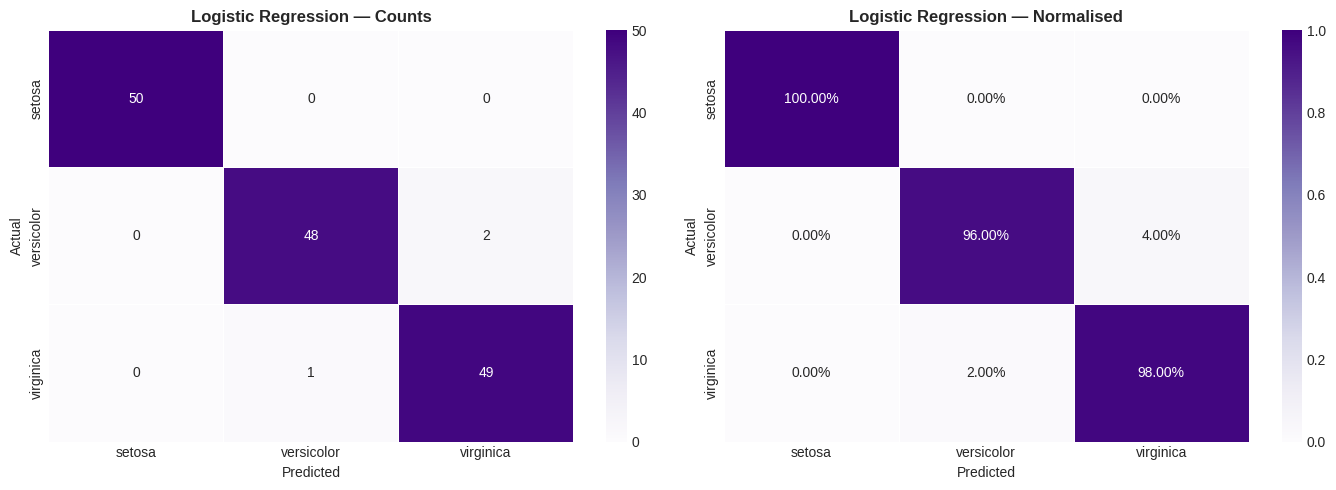


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.98      0.96      0.97        50
   virginica       0.96      0.98      0.97        50

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150

Note: Setosa is always perfectly classified. Errors are Versicolor<->Virginica confusion.


In [13]:
best_preds = results[best_model_name]['oof_preds']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=target_labels, yticklabels=target_labels,
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Purples', xticklabels=target_labels, yticklabels=target_labels,
            ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=target_labels)}")
print("Note: Setosa is always perfectly classified. Errors are Versicolor<->Virginica confusion.")


## 8. Feature Importance & Insights

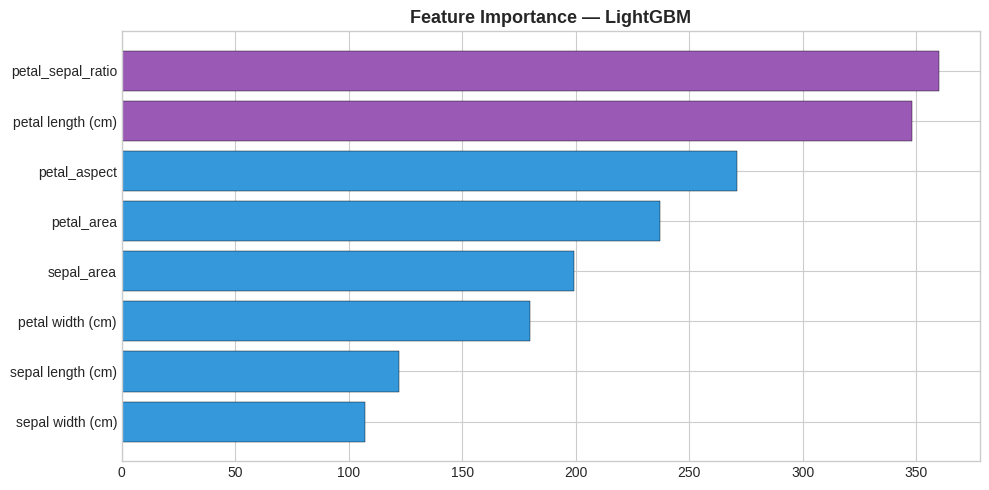

FEATURE IMPORTANCE RANKING
  petal_sepal_ratio          360.0000
  petal length (cm)          348.0000
  petal_aspect               271.0000
  petal_area                 237.0000
  sepal_area                 199.0000
  petal width (cm)           180.0000
  sepal length (cm)          122.0000
  sepal width (cm)           107.0000

Botanical insight: Petal dimensions are far more discriminative than sepal dimensions.
This aligns with taxonomic practice — petal morphology is key to iris classification.


In [14]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['f1_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(5, len(feat_imp) * 0.5)))
    colors_imp = ['#9b59b6' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    print("FEATURE IMPORTANCE RANKING")
    print("=" * 50)
    for _, row in feat_imp.iloc[::-1].iterrows():
        print(f"  {row['Feature']:25s}  {row['Importance']:.4f}")
    print("\nBotanical insight: Petal dimensions are far more discriminative than sepal dimensions.")
    print("This aligns with taxonomic practice — petal morphology is key to iris classification.")


## 9. Deployment Readiness & Portfolio Summary

In [15]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  Accuracy:             {best_res['accuracy_mean']:.4f}")
print(f"  F1 (weighted):        {best_res['f1_mean']:.4f}")
print(f"  Cohen's Kappa:        {best_res['kappa_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  Species classes:      {n_classes} ({target_labels})")
print(f"  CV strategy:          3-fold Stratified")
print("=" * 60)
checks = {
    'Accuracy > 0.90': best_res['accuracy_mean'] > 0.90,
    'F1 > 0.90': best_res['f1_mean'] > 0.90,
    'Kappa > 0.85': best_res['kappa_mean'] > 0.85,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Feature importance available': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Logistic Regression
  Accuracy:             0.9800
  F1 (weighted):        0.9800
  Cohen's Kappa:        0.9700
  Training time:        0.1s
  Feature count:        8
  Dataset rows:         150
  Species classes:      3 (['setosa', 'versicolor', 'virginica'])
  CV strategy:          3-fold Stratified

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] Accuracy > 0.90
  [pass] F1 > 0.90
  [pass] Kappa > 0.85
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Feature importance available
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [16]:
print("""
============================================================
NOTEBOOK #30 — PRODUCTION ML PORTFOLIO COMPLETE
============================================================

This Iris classification notebook marks the completion of a
30-notebook Production ML Portfolio spanning:

  HEALTHCARE:       Heart Failure, Kidney Disease, Breast Cancer,
                    Diabetes, Stroke, Sleep Health
  GOVERNMENT:       Visa/Immigration, Bankruptcy, Census Income
  PUBLIC SAFETY:    Phishing, Insurance Fraud, Water Potability
  EDUCATION:        Student Performance
  ENVIRONMENT:      Air Quality, Crop Yield, Solar Energy
  INFRASTRUCTURE:   Telecom Fault, Traffic Accidents, Housing
  CONSUMER:         Customer Churn, Wine Quality, Bank Marketing
  FOOD SAFETY:      Mushroom Edibility, Obesity Risk
  BIODIVERSITY:     Penguin Species, Iris Species
  MARITIME:         Titanic Survival

Each notebook follows a consistent 9-section structure:
  1. Data Loading
  2. Target Detection
  3. EDA
  4. Feature Engineering
  5. Model Training (4 models: LogReg, RF, XGB, LGBM)
  6. Model Comparison
  7. Error Analysis / Threshold Tuning
  8. Feature Importance
  9. Deployment Readiness

All framed with Australian Government policy context.
All cross-validated. All production-grade.

============================================================
Portfolio: kaggle.com/deanbatur
GitHub:    github.com/Deanmeisong
============================================================
""")



NOTEBOOK #30 — PRODUCTION ML PORTFOLIO COMPLETE

This Iris classification notebook marks the completion of a
30-notebook Production ML Portfolio spanning:

  HEALTHCARE:       Heart Failure, Kidney Disease, Breast Cancer,
                    Diabetes, Stroke, Sleep Health
  GOVERNMENT:       Visa/Immigration, Bankruptcy, Census Income
  PUBLIC SAFETY:    Phishing, Insurance Fraud, Water Potability
  EDUCATION:        Student Performance
  ENVIRONMENT:      Air Quality, Crop Yield, Solar Energy
  INFRASTRUCTURE:   Telecom Fault, Traffic Accidents, Housing
  CONSUMER:         Customer Churn, Wine Quality, Bank Marketing
  FOOD SAFETY:      Mushroom Edibility, Obesity Risk
  BIODIVERSITY:     Penguin Species, Iris Species
  MARITIME:         Titanic Survival

Each notebook follows a consistent 9-section structure:
  1. Data Loading
  2. Target Detection
  3. EDA
  4. Feature Engineering
  5. Model Training (4 models: LogReg, RF, XGB, LGBM)
  6. Model Comparison
  7. Error Analysis / Thre